# Notebook Statapp

# Phishing emails classifier

## Librairies

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import kagglehub
import os
import shutil
import regex as re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
import unicodedata
from sklearn.naive_bayes import MultinomialNB
from nltk.tokenize import word_tokenize
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
import pickle
tqdm.pandas()

## Classifier data

https://huggingface.co/datasets/SetFit/enron_spam

In [48]:
from datasets import load_dataset

df = load_dataset("SetFit/enron_spam")

# To avoid rewriting code for previous version
df=pd.concat([df["train"].to_pandas(),df["test"].to_pandas()])

df.sample(n=10)

Repo card metadata block was not found. Setting CardData to empty.


,message_id,text,label,label_text,subject,message,date
25235,2809,calpine daily gas nomination we are still unde...,0,ham,calpine daily gas nomination,we are still under the scheduled outage period...,2001-03-21
8380,9044,enron : wefa luncheon may 1 martin :\nvince an...,0,ham,enron : wefa luncheon may 1,martin :\nvince and lance want you to attend t...,2001-04-13
11064,17399,schedule crawler : hourahead failure start dat...,0,ham,schedule crawler : hourahead failure,start date : 12 / 22 / 01 ; hourahead hour : 2...,2001-12-22
4083,9978,your logo and visual identity from us thinking...,1,spam,your logo and visual identity from us,thinking of breathing new life into your busin...,2005-06-21
30033,7423,metals curves hi maureen\ni hope you ' re keep...,0,ham,metals curves,hi maureen\ni hope you ' re keeping well . lon...,2000-10-27
891,10733,dowlnoadable 70 + xxx vldeos with pornstars - ...,1,spam,dowlnoadable 70 + xxx vldeos with pornstars - ...,we have the hottest pornostars pics and videos...,2005-07-15
2706,24783,market internet access - no investment needed ...,1,spam,market internet access - no investment needed,market internet access\nno investment needed\n...,2002-08-25
14773,832,june 2000 availabilities - 2 nd revision chang...,0,ham,june 2000 availabilities - 2 nd revision,"changes apply to eugene island ( sonat ) , gar...",2000-05-26
13376,11319,fw : extension of petro - canada wholesale gas...,0,ham,fw : extension of petro - canada wholesale gas...,for 5 more years\nafter a great deal of work t...,2001-03-28
21150,15307,always wanted an expensive watch such as a rol...,1,spam,,always wanted an expensive watch such as a rol...,2004-10-20


In [50]:
df.rename(columns={"text":"body"},inplace=True)
original_df=df.copy()

Saving data

In [24]:
#!mkdir data
#df.to_csv("enron_data.csv")
#!mv enron_data.csv data


Counting fake vs true

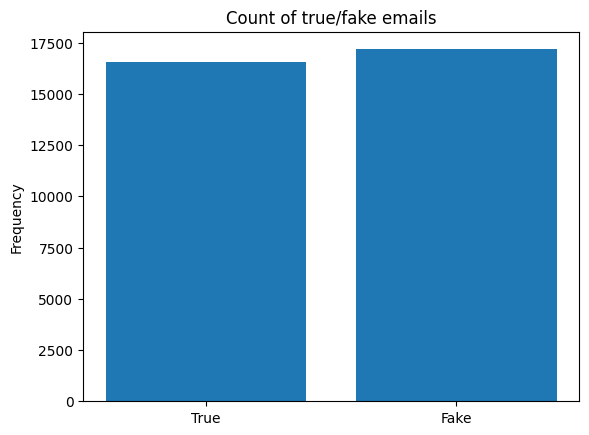

In [25]:
plt.hist(df.loc[:,'label'], bins=[-0.5,0.5,1.5] ,rwidth=0.8)
plt.xticks([0,1],['True','Fake'])
plt.ylabel("Frequency")
plt.title("Count of true/fake emails")
plt.show()

Balanced Dataset

## Data preprocessing

### Cleaning

In [26]:



def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    try:
        text = unicodedata.normalize("NFKC", text)  # Normalize characters
    except:
        print(text)
        return
    text = str(text).lower()
    sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
    for sequence in sequences:
        text=re.sub(sequence,'',text)
    
    return text

<>:14: SyntaxWarning: invalid escape sequence '\['
<>:14: SyntaxWarning: invalid escape sequence '\S'
<>:14: SyntaxWarning: invalid escape sequence '\w'
<>:14: SyntaxWarning: invalid escape sequence '\['
<>:14: SyntaxWarning: invalid escape sequence '\S'
<>:14: SyntaxWarning: invalid escape sequence '\w'
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_1394/1313633118.py:14: SyntaxWarning: invalid escape sequence '\['
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_1394/1313633118.py:14: SyntaxWarning: invalid escape sequence '\S'
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_1394/1313633118.py:14: SyntaxWarning: invalid escape sequence '\w'
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.

In [27]:
df['body']=df['body'].apply(clean_text)

In [28]:
df.sample(n=10)['body']

29690    newsletter service hi did you have any e mail ...
17895    about your application we tried to contact you...
19194    mid day volume surge patchinternational  inc  ...
8743     do you like computers incredible offers window...
28066    save your money buy getting this thing here yo...
1096     it works fine cialis valllum vlaggra hello  we...
10518    loa  message from fred lange fyi  it sounds li...
10120    spring  conference participation by jeffrey k ...
18047    tramadool  merldlla    aluum  xana  loraazepam...
15855    make photo cops ineffective this spray works r...
Name: body, dtype: object

#### Stopwords + Lemmatization

In [29]:
sw=set(stopwords.words('english') + ['hou','ect'])
lemmatizer = WordNetLemmatizer()


def stop_lem(text):
    text=' '.join(word for word in text.split(' ') if word not in sw)
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split(' '))

df['body']=df['body'].progress_apply(stop_lem)

100%|██████████| 33716/33716 [00:18<00:00, 1813.05it/s]


In [30]:
df.sample(n=10)["body"]

149      wharton guy  first  louise  understand baby   ...
23574    omc software cheap  top quality software speci...
15736     mpc march  b checked counterparties according...
27918    revised availability                       for...
10342    following budget review meeting set ken lay  g...
6712     get tramadol  strongest pain killer  tramadol ...
17864    urgent call mr  silas sankohecobank beninrue d...
3039     marathon oil company meter    nacogodoches co ...
29035    fino  gel lubricante   sino puede ver este cor...
15419    life general good god     find time  write boo...
Name: body, dtype: object

Helper function for future texts

In [35]:
def preprocessing(text):
    return stop_lem(clean_text(text))
    
preprocessing("Ronaldo began his senior career with Sporting CP, before signing with Manchester United in 2003, winning the FA Cup in his first season. He went on to win three consecutive Premier League titles, the Champions League and the FIFA Club World Cup; at age 23, he won his first Ballon d'Or.")

'ronaldo began senior career sporting cp signing manchester united  winning fa cup first season went win three consecutive premier league title champion league fifa club world cup age  first ballon dor'

To make data manipulation easier

In [36]:
true_df,fake_df=df.loc[df['label']==0],df.loc[df['label']==1]

## Descriptive statistics/visualisations

### Wordclouds

(-0.5, 399.5, 199.5, -0.5)

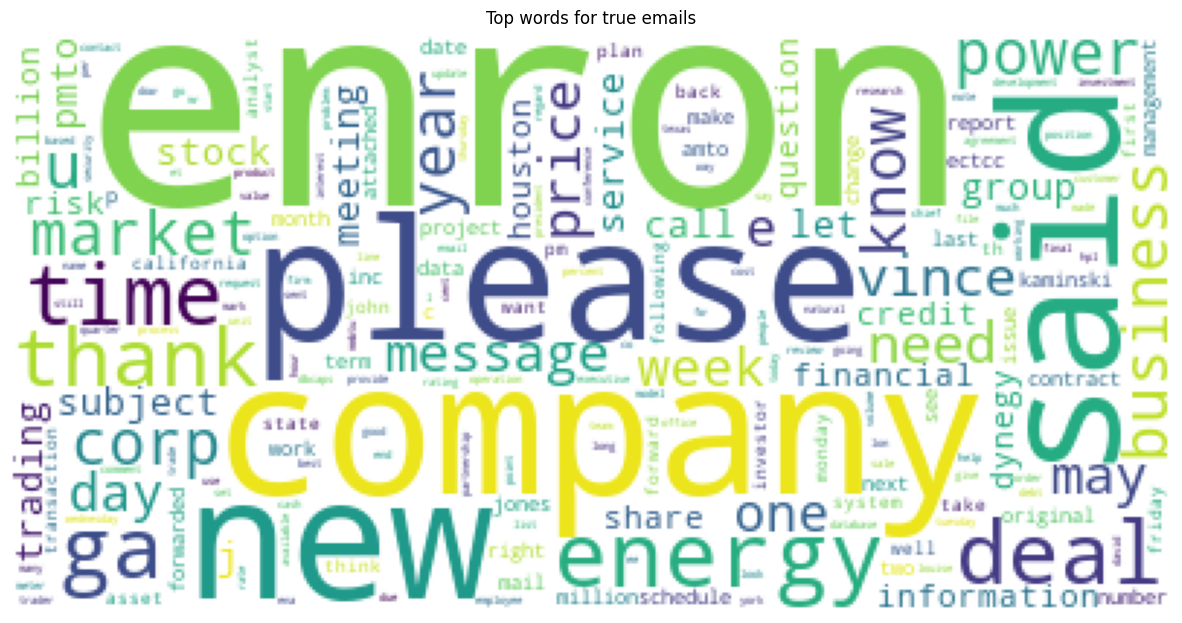

In [37]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in true_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for true emails')
plt.imshow(wc)
plt.axis("off")

(-0.5, 399.5, 199.5, -0.5)

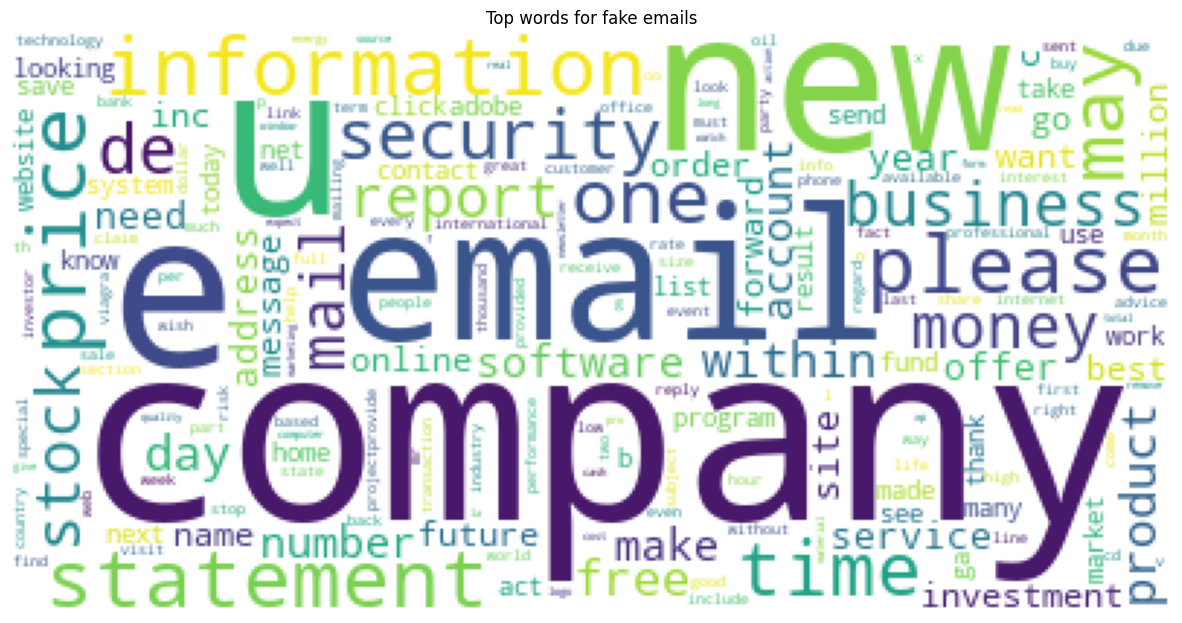

In [38]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in fake_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for fake emails')
plt.imshow(wc)
plt.axis("off")

100%|██████████| 17171/17171 [00:00<00:00, 618668.13it/s]


Text(0.5, 1.0, 'KDE plot')

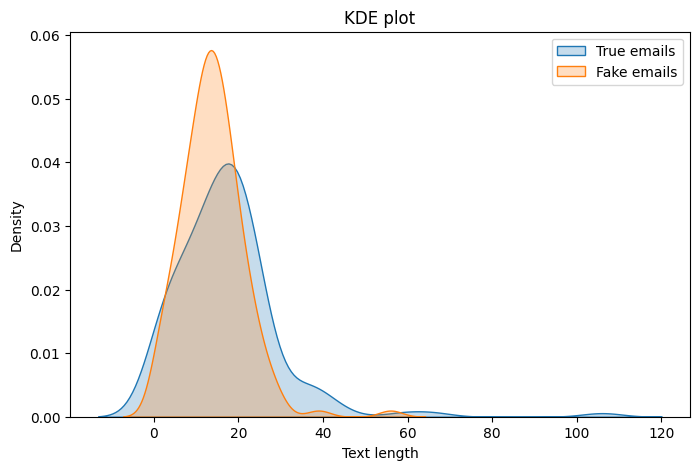

In [39]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['body'].progress_apply(len).value_counts().sort_index()[:150], fill=True,label='True emails')  
sns.kdeplot(fake_df['body'].progress_apply(len).value_counts().sort_index()[:150], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Text length")
plt.ylabel("Density")
plt.title("KDE plot")


### Zipf law

Dictionaries with word counts

In [40]:
def count_dict(data):
    words=''.join(text for text in data['body']).split(' ')
    word_counts={}
    for word in tqdm((words)):
        word_counts[word]=word_counts.get(word,0) + 1
    word_counts.pop('')
    s=sum(word_counts.values())
    return {k:v/s for k,v in word_counts.items()}
true_word_count=count_dict(true_df)
fake_word_count=count_dict(fake_df)

100%|██████████| 2979508/2979508 [00:00<00:00, 4468911.46it/s]


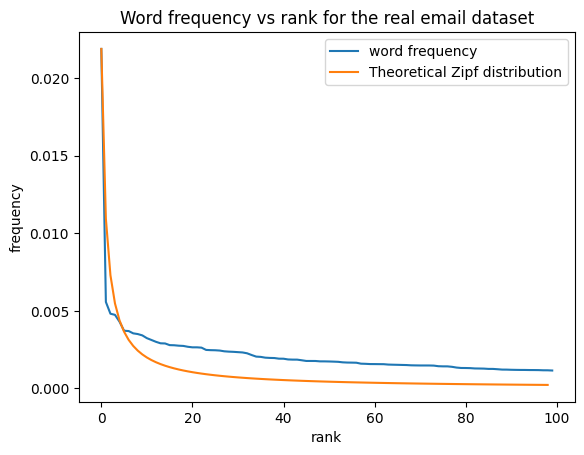

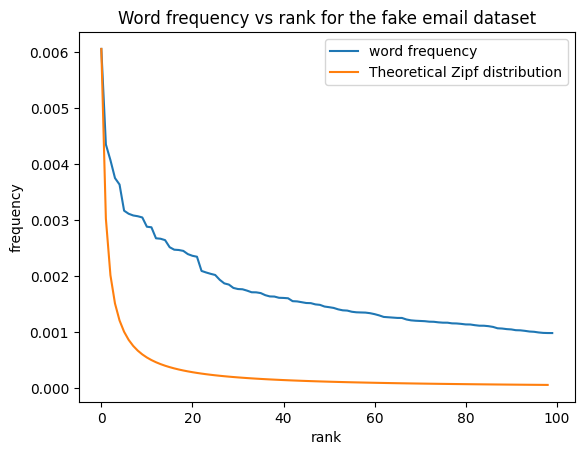

In [41]:

plt.plot(list(sorted(true_word_count.values(),reverse=True))[:100],label='word frequency')
plt.plot([max(list(true_word_count.values()))/(x) for x in np.arange(100)[1:]],label='Theoretical Zipf distribution')
plt.ylabel('frequency')
plt.xlabel('rank')
plt.title('Word frequency vs rank for the real email dataset')
plt.legend()
plt.show()
plt.plot(list(sorted(fake_word_count.values(),reverse=True))[:100],label='word frequency')
plt.plot([max(list(fake_word_count.values()))/x for x in np.arange(100)[1:]],label='Theoretical Zipf distribution')
plt.ylabel('frequency')
plt.xlabel('rank')
plt.title('Word frequency vs rank for the fake email dataset')
plt.legend()

We observe that the word frequency curve for the real email dataset fits the theoretical zipf distribution way more than the fake email dataset

### Sentiment Analysis

In [42]:

def gen_sentiment(df,col):
    def pol(x):
        try:
            return TextBlob(x).sentiment.polarity
        except:
            return x
    def sub(x):
        try:
            return TextBlob(x).sentiment.subjectivity
        except:
            return x


    df["polarity"]=df[col].progress_apply(pol)
    df["subjectivity"]=df[col].progress_apply(sub)
    
    
gen_sentiment(true_df,'subject')
gen_sentiment(fake_df,'subject')


100%|██████████| 16545/16545 [00:01<00:00, 15153.44it/s]
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_1394/1947804801.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["polarity"]=df[col].progress_apply(pol)
100%|██████████| 16545/16545 [00:01<00:00, 15534.38it/s]
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_1394/1947804801.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["subjectivity"]=df[col].progress_apply(sub)
100%|██████████| 17171/17171 [00:01<00:00, 14692.20i

Text(0.5, 1.0, 'Density estimation of subjectivity')

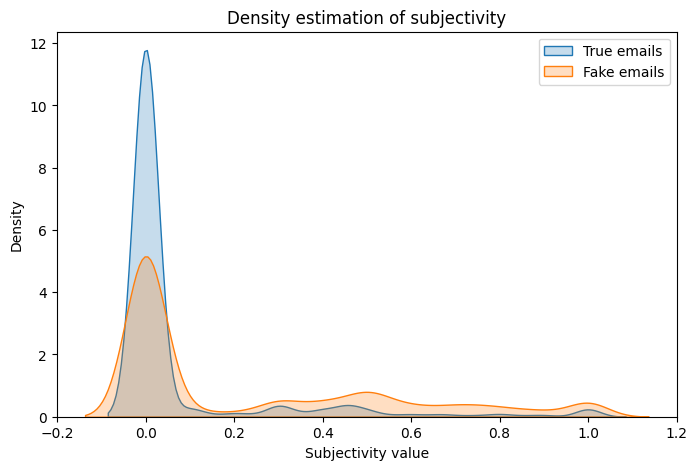

In [43]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['subjectivity'],fill=True,label='True emails')  
sns.kdeplot(fake_df['subjectivity'], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Subjectivity value")
plt.ylabel("Density")
plt.title("Density estimation of subjectivity")


Text(0.5, 1.0, 'Density estimation of polarity')

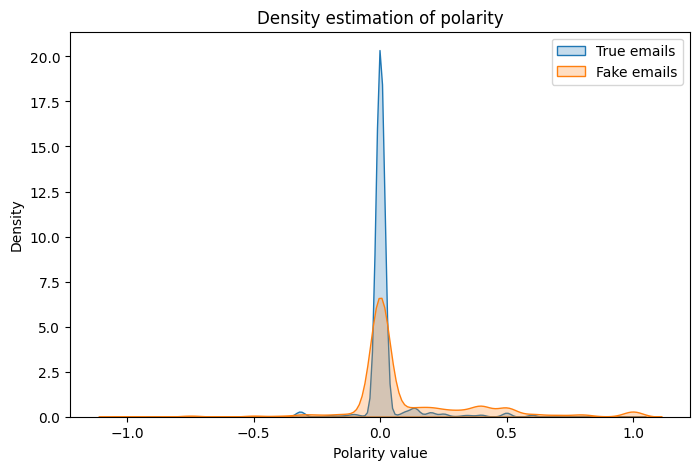

In [44]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['polarity'],fill=True,label='True emails')  
sns.kdeplot(fake_df['polarity'], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Polarity value")
plt.ylabel("Density")
plt.title("Density estimation of polarity")


We see that sentiment distributions for real emails seem to be way closer to the mean value (neutral value) than for fake emails

In [52]:
original_df

,message_id,body,label,label_text,subject,message,date
0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13
...,...,...,...,...,...,...,...
1995,6578,re : book notes vince : look forward to meetin...,0,ham,re : book notes,vince : look forward to meeting you . . .\namy...,2000-07-26
1996,128,rollout schedule for unify real - time deal / ...,0,ham,rollout schedule for unify real - time deal / ...,a walk - thru / demo of this new functionality...,2000-01-11
1997,8485,anshuman shrivastava sandeep : vince has asked...,0,ham,anshuman shrivastava,sandeep : vince has asked me to coordinate wit...,2001-02-06
1998,7311,"re : good morning john ,\ni shall see christie...",0,ham,re : good morning,"john ,\ni shall see christie tomorrow and i sh...",2000-10-18


In [60]:
df

,message_id,body,label,label_text,subject,message,date,hyperlink_count,attachment_count
0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18,0,0
1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19,0,0
2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11,0,0
3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12,0,0
4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13,0,0
...,...,...,...,...,...,...,...,...,...
1995,6578,re : book notes vince : look forward to meetin...,0,ham,re : book notes,vince : look forward to meeting you . . .\namy...,2000-07-26,0,0
1996,128,rollout schedule for unify real - time deal / ...,0,ham,rollout schedule for unify real - time deal / ...,a walk - thru / demo of this new functionality...,2000-01-11,0,0
1997,8485,anshuman shrivastava sandeep : vince has asked...,0,ham,anshuman shrivastava,sandeep : vince has asked me to coordinate wit...,2001-02-06,0,0
1998,7311,"re : good morning john ,\ni shall see christie...",0,ham,re : good morning,"john ,\ni shall see christie tomorrow and i sh...",2000-10-18,0,0


### Hyperlink count 

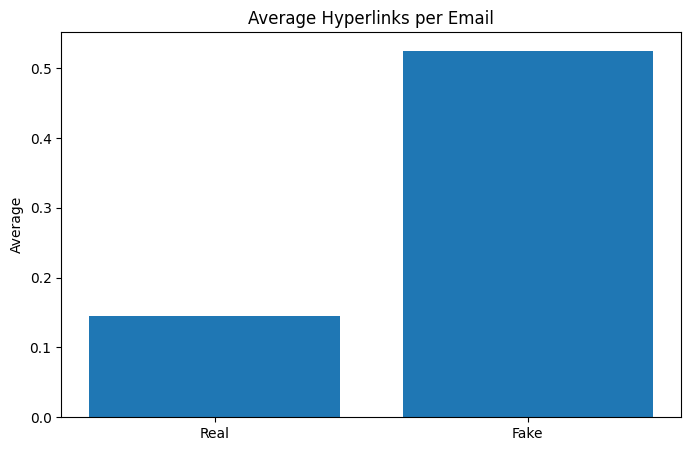

In [76]:

def count_hyperlinks(text):
    return len(re.findall(r'http+', text))

def count_attachments(text):
    return len(re.findall(r'attachment|file|pdf|image|zip|doc', text, re.IGNORECASE))


df["hyperlink_count"] = original_df["body"].apply(count_hyperlinks)


fig, ax = plt.subplots(1, 1, figsize=(8, 5))


ax.bar(["Real", "Fake"], df.groupby("label")["hyperlink_count"].mean())
ax.set_title("Average Hyperlinks per Email")
ax.set_ylabel("Average")

plt.show()

### Email time period 

On month

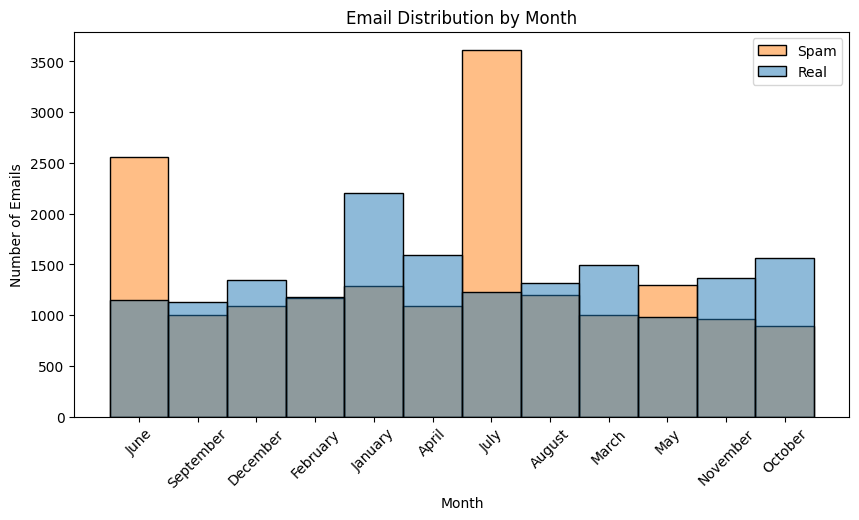

In [140]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["month"] = df["date"].dt.month_name()

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="month", bins=12, hue=df["label"],discrete=True)


plt.xlabel("Month")
plt.ylabel("Number of Emails")
plt.title("Email Distribution by Month")
plt.legend(labels=["Spam","Real"])
plt.xticks(rotation=45) 

plt.show()

On day in the month

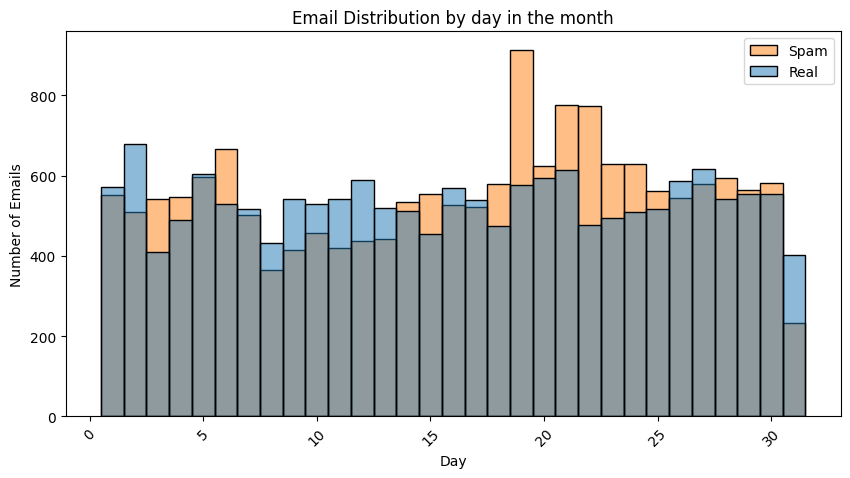

In [122]:
df["month_day"] = df["date"].apply(lambda x:x.day)

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="month_day", bins=31, hue=df["label"],discrete=True)


plt.xlabel("Day")
plt.ylabel("Number of Emails")
plt.title("Email Distribution by day in the month")
plt.legend(labels=["Spam","Real"])
plt.xticks(rotation=45) 

plt.show()

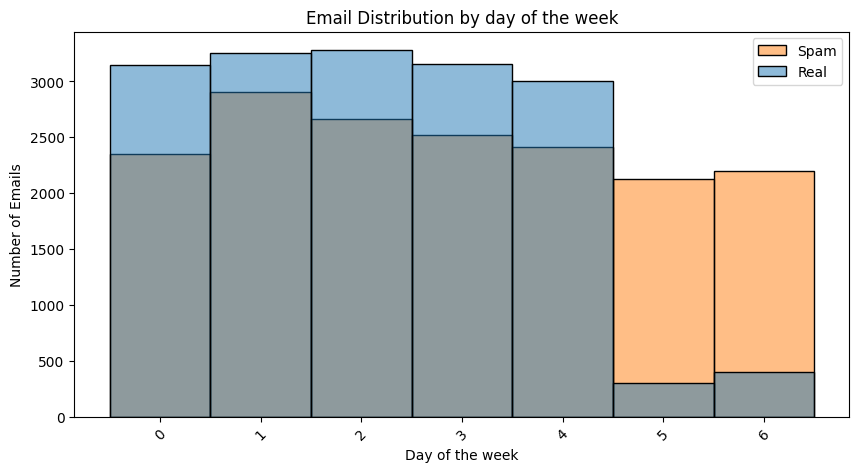

In [139]:
df["weekday"] = df["date"].apply(lambda x:x.weekday())

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="weekday", bins=31, hue=df["label"],discrete=True)


plt.xlabel("Day of the week")

plt.ylabel("Number of Emails")
plt.title("Email Distribution by day of the week")
plt.xticks(rotation=45) 
plt.legend(labels=["Spam","Real"])

plt.show()

0: Monday, 6:Saturday

# Model

## Count vector encoding

Seperating dataset into training and validation

In [131]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df["body"],df["label"],random_state=42)

In [132]:
x_train.sample(n=10), y_train.sample(n=10)

(12500    more jcc the historical context . . .\n- - - -...
 27528    bounce skel @ iit . demokritos . gr : non - me...
 28101    private offer notaris public international\n( ...
 4033     socal rls tariff / peaking rates attached belo...
 21166    long time customer id : 615\norder # 13\nwe wo...
 22548    briana mcintyre wed , 20 jul 2005 02 : 25 : 12...
 6372     fw : two major inconsistencies in ferc ' s mos...
 18147    we are calling for nomination . you ' ve heard...
 20595    re : congestion as indicated , we got that exa...
 440      perfect logo charset = koi 8 - r " > thinking ...
 Name: body, dtype: object,
 18764    1
 20914    1
 15245    0
 8378     0
 15675    0
 18120    0
 29036    0
 404      1
 23327    0
 18454    1
 Name: label, dtype: int64)

In [133]:


vect=CountVectorizer()
vect.fit(x_train)


x_train=vect.transform(x_train)
x_test=vect.transform(x_test)

## Naive Bayes Model

In [134]:


nb = MultinomialNB()

nb.fit(x_train, y_train)

MultinomialNB()

0.9889666627120655

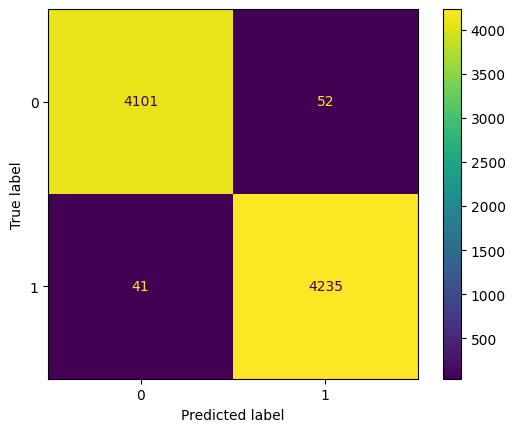

In [135]:
y_pred=nb.predict(x_test)

c_mat=confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(c_mat).plot()
accuracy_score(y_test,y_pred)

In [136]:
pickle.dump(nb,open("multinomial_nb_model.pkl", "wb"))

In [137]:
!mkdir models
!mv multinomial_nb_model.pkl models

In [138]:
def predict(text_list):
    "Array of naive bayes model prediction for all texts in text_list"
    return nb.predict(vect.transform(np.array([preprocessing(text) for text in text_list])))

predict(["Ceci est un premier test",'Deuxième test'])

array([1, 0])

In [81]:
!pipreqsnb main.ipynb --force

<unknown>:14: SyntaxWarning: invalid escape sequence '\['
<unknown>:14: SyntaxWarning: invalid escape sequence '\S'
<unknown>:14: SyntaxWarning: invalid escape sequence '\w'
pipreqs  --force --savepath requirements.txt /Users/Riyad/Documents/2A/Statapp/Statapp-Phishing/__temp_pipreqsnb_folder
INFO: Not scanning for jupyter notebooks.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
INFO: Successfully saved requirements file in requirements.txt
